In [1]:
print("Hello")

Hello


Missmatch:

0->7
7->7
12->12
17->0
20->17

0->
7->12
12->
17->17
20->20

In [22]:
import pickle
import os

with open("conv_mse_per_id_02.pkl", "rb") as f:
    divs = pickle.load(f)
print(divs)

{1000003: np.float32(2402.9712), 1000004: np.float32(2930.3115), 1000005: np.float32(906.84094), 1000006: np.float32(310.90784), 1000008: np.float32(60.078983), 1000010: np.float32(210.37637), 1000011: np.float32(236.03548), 1000012: np.float32(4155.2803), 1000014: np.float32(153.78996), 1000015: np.float32(872.33875), 1000017: np.float32(2443.5059), 1000018: np.float32(1159.4103), 1000019: np.float32(605.6817), 1000021: np.float32(1555.6328), 1000023: np.float32(1780.4026), 1000025: np.float32(706.1779), 1000026: np.float32(506.12628), 1000033: np.float32(9724.5625), 1000037: np.float32(518.37964), 1000040: np.float32(1765.3271), 1000042: np.float32(147.47514), 1000043: np.float32(2412.5786), 1000045: np.float32(379.15964), 1000046: np.float32(66.04101), 1000048: np.float32(213.59846), 1000049: np.float32(1320.5028), 1000050: np.float32(704.4493), 1000053: np.float32(304.1579), 1000056: np.float32(568.6865), 1000059: np.float32(1760.8938), 1000060: np.float32(2277.7212), 1000061: np.f

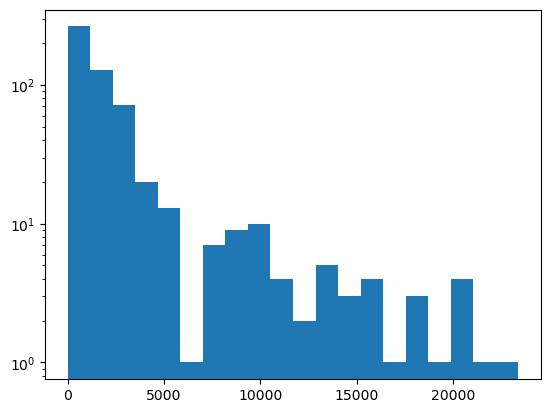

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# plot histogram of divs
plt.hist(list(divs.values()), bins=20)
# log y axis
plt.yscale("log")

plt.show()

In [ ]:
ids_to_save = [id for id, div in divs.items() if 6000 < div ]
print(ids_to_save)
print(len(ids_to_save))
print(divs[1000101])
print(divs[1000171])
print(divs[1000166])
print(divs[1000033])


[1000033, 1000101, 1000152, 1000162, 1000171, 1000415, 1000774, 1000970, 1001735, 1002533, 1002661, 1006419, 1036087, 1036088, 1036111, 1036130, 1036131, 1036132, 1036134, 1036137, 1036141, 1036143, 1036145, 1036146, 1036148, 1036157, 1036158, 1036159, 1036160, 1036162, 1036163, 1036164, 1036165, 1036178, 1036187, 1036188, 1036189, 1036190, 1036216, 1036229, 1036230, 1036236, 1036240, 1036241, 1036244, 1036245, 1036250, 1036251, 1036270, 1036272, 1036273, 1036275, 1036281, 1036285, 1036291, 1036298]
56
8259.713
13684.272
2533.7715
9724.5625


In [4]:
import Parallel_stuff

e171 = {}
e171[0] = Parallel_stuff.load_exr_from_id(171, 0)
e171[7] = Parallel_stuff.load_exr_from_id(171, 7)
e171[12] = Parallel_stuff.load_exr_from_id(171, 12)
e171[17] = Parallel_stuff.load_exr_from_id(171, 17)
e171[20] = Parallel_stuff.load_exr_from_id(171, 20)

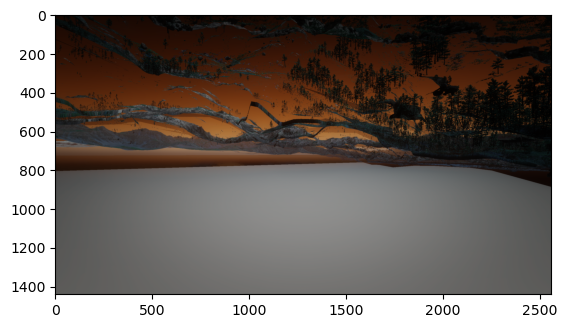

In [5]:
plt.imshow(e171[0])

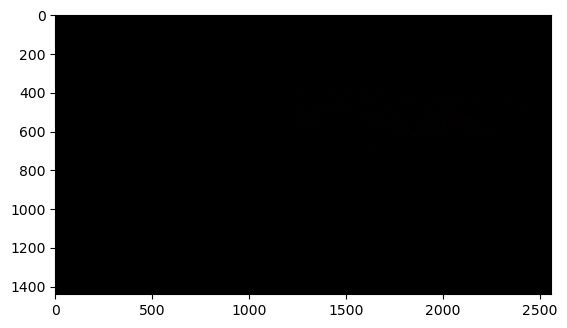

In [6]:
conv_e171_0 = Parallel_stuff.convolve_with_DoG(e171[0])
plt.imshow(conv_e171_0)

In [12]:
import cv2
kernel_size = 5
sigma = 1.0
k1 = cv2.getGaussianKernel(kernel_size, sigma)
k2 = cv2.getGaussianKernel(kernel_size, sigma * 1.6)
dog_kernel = k1 - k2

normalized_dog_kernel = dog_kernel / np.sum(np.abs(dog_kernel))
normalized_dog_kernel

array([[-0.25      ],
       [ 0.04452079],
       [ 0.41095843],
       [ 0.04452079],
       [-0.25      ]])

In [15]:
import pickle

with open("mean_ratios_canny.pkl", "rb") as f:
    mean_ratios_canny= pickle.load(f)
mean_ratios_canny


{(1000003, '0'): np.float64(82316080.72942926),
 (1000003, '12'): np.float64(65262125651.08026),
 (1000003, '17'): np.float64(15101196289.127817),
 (1000003, '20'): np.float64(5787027994.816942),
 (1000003, '7'): np.float64(6329345703.1515255),
 (1000004, '0'): np.float64(0.0),
 (1000004, '12'): np.float64(19818806966.176662),
 (1000004, '17'): np.float64(4271443684.9362707),
 (1000004, '20'): np.float64(204060872.39724582),
 (1000004, '7'): np.float64(416422526.04452014),
 (1000005, '0'): np.float64(2766927.083384603),
 (1000005, '12'): np.float64(10252848307.300924),
 (1000005, '17'): np.float64(1827555338.55477),
 (1000005, '20'): np.float64(280151367.1893886),
 (1000005, '7'): np.float64(962890625.0073559),
 (1000006, '0'): np.float64(64331054.68756022),
 (1000006, '12'): np.float64(7906494140.646935),
 (1000006, '17'): np.float64(1969360351.5738747),
 (1000006, '20'): np.float64(130045572.91754584),
 (1000006, '7'): np.float64(143188476.56351617),
 (1000008, '0'): np.float64(23034

In [22]:
# Create list of all ids with a mean ratio above 0.5
ids_above_0_5 = [id for id, ratio in mean_ratios_canny.items() if ratio > 60000000000.0]
print(ids_above_0_5)

# Create a set of all ids without times with a mean ratio above 0.5
ids_without_times_above_0_5 = [id for id, time in ids_above_0_5]
print(ids_without_times_above_0_5)
ids_above_0_5_set = set(ids_without_times_above_0_5)
print(ids_above_0_5_set)
print(len(ids_above_0_5_set))

[(1000003, '12'), (1000025, '12'), (1000101, '0'), (1000101, '12'), (1000136, '20'), (1000136, '7'), (1000171, '0'), (1000171, '12'), (1000171, '17'), (1000171, '20'), (1000235, '20'), (1000305, '20'), (1000339, '7'), (1000385, '0'), (1000442, '0'), (1000456, '20'), (1000549, '20'), (1000702, '7'), (1000812, '0'), (1000966, '7'), (1001082, '12'), (1001082, '7'), (1001145, '7'), (1001189, '0'), (1001899, '20'), (1002193, '12'), (1002193, '7'), (1002385, '7'), (1003783, '7'), (1004849, '0'), (1004891, '20'), (1005680, '7'), (1005704, '7'), (1007004, '12'), (1007510, '7'), (1014627, '0'), (1014627, '20'), (1014627, '7'), (1016294, '7'), (1018863, '20'), (1023710, '20'), (1025032, '7'), (1026896, '0'), (1031718, '12'), (1031806, '7'), (1031839, '0'), (1031839, '12'), (1031839, '7'), (1031842, '12'), (1031944, '12'), (1031944, '20'), (1031947, '12'), (1031947, '20'), (1031947, '7'), (1031956, '0'), (1031956, '20'), (1032127, '12'), (1032145, '12'), (1032207, '12'), (1032207, '7'), (1032401,

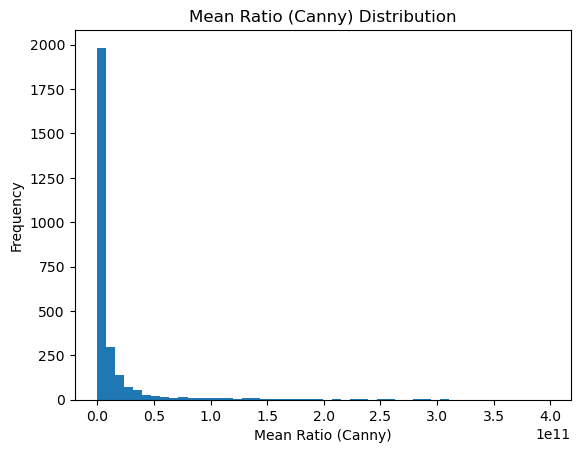

In [8]:
# Plot mean ratio histogram
import matplotlib.pyplot as plt
plt.hist(mean_ratios_canny.values(), bins=50)
plt.title("Mean Ratio (Canny) Distribution")
plt.xlabel("Mean Ratio (Canny)")
plt.ylabel("Frequency")
plt.show()

In [2]:
import pickle

with open("../divs.pkl", "rb") as f:
    divs = pickle.load(f)
divs

{(1000003, '0'): np.float64(3.448017120838946),
 (1000003, '12'): np.float64(6.107541019414322),
 (1000003, '17'): np.float64(5.0567732346033765),
 (1000003, '20'): np.float64(6.9939056151659305),
 (1000003, '7'): np.float64(7.2607683461339185),
 (1000004, '0'): np.float64(9.281053057323902),
 (1000004, '12'): np.float64(8.788729019423387),
 (1000004, '17'): np.float64(7.478660816330764),
 (1000004, '20'): np.float64(7.570006659167882),
 (1000004, '7'): np.float64(7.276480039302461),
 (1000005, '0'): np.float64(6.066012413610228),
 (1000005, '12'): np.float64(10.727262942831526),
 (1000005, '17'): np.float64(7.734474077689509),
 (1000005, '20'): np.float64(7.595419379630158),
 (1000005, '7'): np.float64(5.2147171775889),
 (1000006, '0'): np.float64(4.703957020978345),
 (1000006, '12'): np.float64(6.947979566230719),
 (1000006, '17'): np.float64(6.041086814707384),
 (1000006, '20'): np.float64(5.378630025074791),
 (1000006, '7'): np.float64(6.849831642300069),
 (1000008, '0'): np.float6

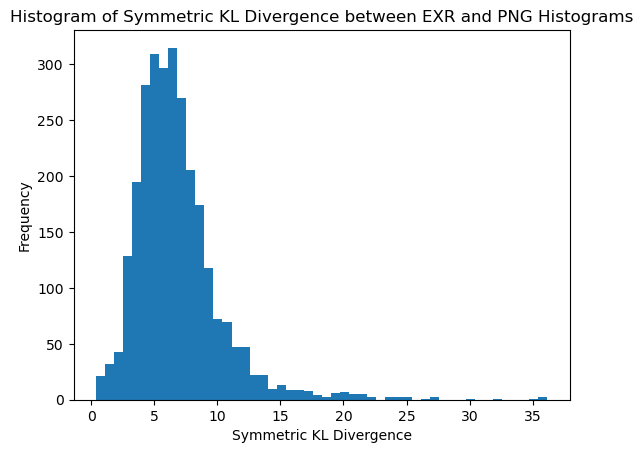

In [3]:
# plot histogram of divs
import matplotlib.pyplot as plt
plt.hist(list(divs.values()), bins=50)
plt.xlabel("Symmetric KL Divergence")
plt.ylabel("Frequency")
plt.title("Histogram of Symmetric KL Divergence between EXR and PNG Histograms")
plt.show()

In [4]:
# Get the 10 files with divergence larger than 10
divs_above_threshold = {k: v for k, v in divs.items() if v > 10}
print(f"Number of files with Symmetric KL Divergence above 10: {len(divs_above_threshold)}")
print("Files with Symmetric KL Divergence above 10:")
for id_time, divergence in divs_above_threshold.items():
    print(f"{id_time}: {divergence}")
    

Number of files with Symmetric KL Divergence above 10: 336
Files with Symmetric KL Divergence above 10:
(1000005, '12'): 10.727262942831526
(1000011, '12'): 12.883799387487858
(1000011, '17'): 12.9331467663484
(1000011, '7'): 12.008149739067179
(1000012, '12'): 17.196141069290668
(1000012, '17'): 19.205551164913096
(1000012, '7'): 10.79261774961787
(1000014, '17'): 11.189962863400899
(1000015, '17'): 11.1037785785839
(1000019, '17'): 20.31035727593497
(1000021, '0'): 12.354979993444541
(1000021, '12'): 17.210688950414628
(1000021, '17'): 16.628562613865547
(1000021, '20'): 13.745240745004255
(1000021, '7'): 15.99949691925925
(1000026, '17'): 11.233518794711657
(1000026, '20'): 10.606762824602686
(1000042, '20'): 10.126526307838908
(1000043, '12'): 15.940864827864658
(1000043, '17'): 18.812838891182643
(1000043, '20'): 10.223222157914364
(1000043, '7'): 12.08130278756442
(1000045, '17'): 13.157449973457725
(1000049, '12'): 11.453231468490966
(1000050, '20'): 11.044651638933585
(1000060,

In [1]:
# load exr image in numpy array
import numpy as np
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"
import cv2
from pathlib import Path
from tqdm import tqdm

In [3]:
def load_image(file_path):
    if file_path.split(".")[-1].lower() == "exr":
        img = cv2.imread(file_path, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)
        img = np.clip(img, 0, 10)
        # appy Reinhard-tone mapping
        img /= (1.0 + img)
        img *= 255
    else:
        img = cv2.imread(file_path)
    if img is None:
        msg = f"Failed to load image: {file_path}"
        raise ValueError(msg)
    return img.astype(np.uint8)


def get_images_from_id(id, time=0):
    if id < 1000000:
        id = 1000000 + id
    filename_exr = r"D:\Subset\HDR_EXR\h_" + str(id) + "_"+ str(time) +".exr"
    filename_png = r"D:\Subset\PNG\o_" + str(id) + "_"+ str(time) +".png"
    return load_image(filename_exr), load_image(filename_png)

In [ ]:
# Iterate over all files in the directory
import multiprocessing
import tqdm.auto

directory = r"D:\Subset\HDR_EXR"
divs = {}

def process_file(filename):
    id = int(filename.split("_")[1])
    time = filename.split("_")[2].split(".")[0]
    id_time = (id, time)
    exr, png = get_images_from_id(id, int(time))
    hist_exr = np.histogram(exr, bins=256, range=(0, 255), density=True)[0]
    hist_png = np.histogram(png, bins=256, range=(0, 255), density=True)[0]
    kl_div = np.sum(hist_exr * np.log((hist_exr + 1e-10) / (hist_png + 1e-10)))
    symm_kl_div = kl_div + np.sum(hist_png * np.log((hist_png + 1e-10) / (hist_exr + 1e-10)))
    return id_time, symm_kl_div

with multiprocessing.Pool(os.cpu_count()) as process_pool:
    results = dict(
        tqdm.auto.tqdm(
            process_pool.imap(
                process_file,
                os.listdir(directory),
            ),
            total=len(os.listdir(directory)),
            desc="Doing stuff",
            unit="file",
        ),
    )
results

Doing stuff:   0%|          | 0/2765 [00:00<?, ?file/s]

In [12]:
# Iterate over all files in the directory
directory = r"D:\Subset\HDR_EXR"
divs = {}

for filename in tqdm(os.listdir(directory)):
    id = int(filename.split("_")[1])
    time = filename.split("_")[2].split(".")[0]
    id_time = (id, time)
    exr, png = get_images_from_id(id, int(time))
    hist_exr = np.histogram(exr, bins=256, range=(0, 255), density=True)[0]
    hist_png = np.histogram(png, bins=256, range=(0, 255), density=True)[0]
    kl_div = np.sum(hist_exr * np.log((hist_exr + 1e-10) / (hist_png + 1e-10)))
    symm_kl_div = kl_div + np.sum(hist_png * np.log((hist_png + 1e-10) / (hist_exr + 1e-10)))
    divs[id_time] = symm_kl_div

  6%|▌         | 160/2765 [01:42<27:53,  1.56it/s]


KeyboardInterrupt: 

In [8]:
# Iterate over all files in the directory
directory = r"D:\Subset\HDR_EXR"
mean_ratios = []
std_ratios = []

for filename in tqdm(os.listdir(directory)):
    id = int(filename.split("_")[1])
    time = filename.split("_")[2].split(".")[0]
    if time == "0":
        exr, png = get_images_from_id(id, int(time))
        exr_mean = np.mean(exr)
        png_mean = np.mean(png)
        mean_ratio = exr_mean / png_mean if png_mean != 0 else 0
        mean_ratios.append(mean_ratio)
        
        exr_std = np.std(exr)
        png_std = np.std(png)
        std_ratio = exr_std / png_std if png_std != 0 else 0
        std_ratios.append(std_ratio)
# Calculate overall mean and std ratios
overall_mean_ratio_mean = np.mean(mean_ratios) 
overall_mean_ratio_std = np.std(mean_ratios)
overall_std_ratio_mean = np.mean(std_ratios)
overall_std_ratio_std = np.std(std_ratios)
print(f"Overall Mean Ratio: {overall_mean_ratio_mean}")
print(f"Overall Mean Ratio Std: {overall_mean_ratio_std}")
print(f"Overall Std Ratio: {overall_std_ratio_mean}")
print(f"Overall Std Ratio Std: {overall_std_ratio_std}")

100%|██████████| 2765/2765 [06:32<00:00,  7.05it/s]

Overall Mean Ratio: 0.2701974444663575
Overall Mean Ratio Std: 0.4358605606006666
Overall Std Ratio: 0.4792919491952272
Overall Std Ratio Std: 0.6765009115842597


Overall Mean Ratio: 0.2701974444663575

Overall Mean Ratio Std: 0.4358605606006666

Overall Std Ratio: 0.4792919491952272

Overall Std Ratio Std: 0.6765009115842597

In [13]:
# sort mean_ratios and std_ratios by mean_ratios
mean_ratios, std_ratios = zip(*sorted(zip(mean_ratios, std_ratios)))
print("Sorted Mean Ratios:")
print("Min")
print(mean_ratios[:2])
print("Max")
print(mean_ratios[-2:-1])
print("Median")
print(mean_ratios[len(mean_ratios)//2])

print("Sorted Std Ratios:")
print("Min")
print(std_ratios[:2])
print("Max")
print(std_ratios[-2:-1])
print("Median")
print(std_ratios[len(std_ratios)//2])


Sorted Mean Ratios:
Min
(np.float64(0.041088544411890256), np.float64(0.04347824622205577))
Max
(np.float64(2.4372277383924312),)
Median
0.1162296503912831
Sorted Std Ratios:
Min
(np.float64(0.10183601011467645), np.float64(0.2743553814872953))
Max
(np.float64(3.1337585929685368),)
Median
0.2164689641050282


In [ ]:

mean_ratios_gt_1 = sum(1 for r in mean_ratios if r > 0.35)
print(f"Number of mean ratios greater than 0.35: {mean_ratios_gt_1} out of {len(mean_ratios)}")

Number of mean ratios greater than 1: 59 out of 553


In [ ]:

directory = r"D:\Subset\HDR_EXR"
mean_ratios = {}
std_ratios = {}

for filename in tqdm(os.listdir(directory)):
    id = int(filename.split("_")[1])
    time = filename.split("_")[2].split(".")[0]
    exr, png = get_images_from_id(id, int(time))
    exr_canny = cv2.Canny(exr, 100, 200)
    png_canny = cv2.Canny(png, 100, 200)
    ratio = exr_canny/(png_canny + 1e-10)
    mean_ratios[(id, time)] = np.mean(ratio)
    std_ratios[(id, time)] = np.std(ratio)

print("Mean Ratio:")
ratios = list(mean_ratios.values())
print(f"Mean: {np.mean(ratios)}")
print(f"Std: {np.std(ratios)}")

  0%|          | 0/2765 [00:00<?, ?it/s]

100%|██████████| 2765/2765 [04:58<00:00,  9.27it/s]


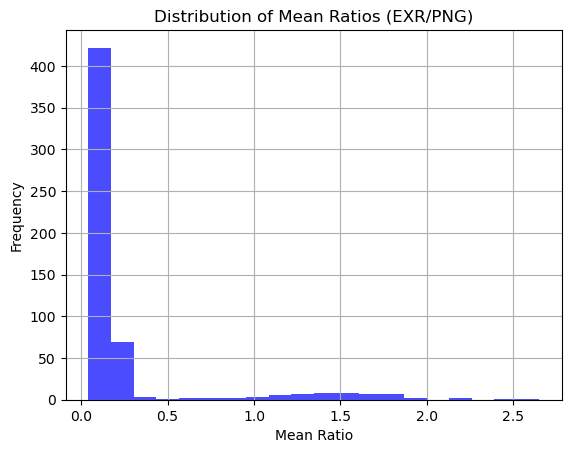

In [6]:
# Plot distribution of mean ratios
import matplotlib.pyplot as plt
plt.hist(list(mean_ratios.values()), bins=20, alpha=0.7, color='blue')
plt.title('Distribution of Mean Ratios (EXR/PNG)')
plt.xlabel('Mean Ratio')
plt.ylabel('Frequency')
plt.grid()
plt.show()


In [8]:
# get all ids where mean ratio is greater than 0.35
ids_gt_035 = [id for id, ratio in mean_ratios.items() if ratio > 0.35]
print(f"IDs with mean ratio greater than 0.35: {ids_gt_035}")

IDs with mean ratio greater than 0.35: [1000019, 1000087, 1000095, 1000101, 1000136, 1000171, 1000233, 1000385, 1000442, 1000763, 1000812, 1001189, 1001677, 1001711, 1003346, 1004849, 1005491, 1005788, 1007510, 1014627, 1019293, 1026896, 1028761, 1028771, 1030767, 1030771, 1031839, 1031956, 1032207, 1032401, 1032501, 1035729, 1035778, 1036087, 1036088, 1036111, 1036131, 1036134, 1036137, 1036145, 1036146, 1036148, 1036157, 1036158, 1036160, 1036162, 1036163, 1036178, 1036186, 1036187, 1036200, 1036240, 1036241, 1036244, 1036245, 1036272, 1036281, 1036291, 1036298]


In [9]:
# iterate over all ids gt 0.35
for id in ids_gt_035:
    for time in [0,7,12,17,20]:
        exr, png = get_images_from_id(id, time)
        # save exr and png to disk
        cv2.imwrite(r"D:\Subset\exr_to_png_wrong_time\h_" + str(id) + f"_{time}.png", exr)
        cv2.imwrite(r"D:\Subset\png_wrong_time\o_" + str(id) + f"_{time}.png", png)

In [ ]:
for filename in os.listdir(directory):
    id = filename.split("_")[1]
    time = filename.split("_")[2].split(".")[0]
    if time == "0":
        exr, png = get_images_from_id(id, int(time))
        exr_mean = np.mean(exr)
        png_mean = np.mean(png)
        mean_ratio = exr_mean / png_mean if png_mean != 0 else 0
        mean_ratios.append(mean_ratio)
        
        exr_std = np.std(exr)
        png_std = np.std(png)
        std_ratio = exr_std / png_std if png_std != 0 else 0
        std_ratios.append(std_ratio)

In [5]:
from pathlib import Path

import cv2

filename = r"D:\Subset\HDR_EXR\h_1000033_12.exr"

img = cv2.imread(filename, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)
if img is None:
    msg = f"Failed to load EXR image: {filename}"
    raise ValueError(msg)
#img = np.clip(img, 0, 10)



# appy Reinhard-tone mapping
img /= (1.0 + img)
img *= 255

# std and mean of the image
print(f"Image shape: {img.shape}")
print(f"Image dtype: {img.dtype}")
print(f"Image min: {img.min()}")
print(f"Image max: {img.max()}")
std = np.std(img)
mean = np.mean(img)
print(f"Image mean: {mean}")
print(f"Image std: {std}")

filename_path = Path(filename)
png_dir = filename_path.parent.parent / "PNG"
new_name = filename_path.name.replace("h_", "o_").replace(".exr", ".png")
png_path = png_dir / new_name

# load png image in numpy array
img_png = cv2.imread(str(png_path), flags=cv2.IMREAD_COLOR)
if img_png is None:
    msg = f"Failed to load PNG image: {png_path}"
    raise ValueError(msg)
print(f"PNG Image shape: {img_png.shape}")
print(f"PNG Image dtype: {img_png.dtype}")
print(f"PNG Image min: {img_png.min()}")
print(f"PNG Image max: {img_png.max()}")
print(f"PNG Image mean: {img_png.mean()}")
print(f"PNG Image std: {img_png.std()}")


Image shape: (1440, 2560, 3)
Image dtype: float32
Image min: 0.0038909318391233683
Image max: 134.78591918945312
Image mean: 27.317026138305664
Image std: 22.611148834228516
PNG Image shape: (1440, 2560, 3)
PNG Image dtype: uint8
PNG Image min: 0
PNG Image max: 255
PNG Image mean: 86.02056260850695
PNG Image std: 47.52908182241654
